# Minería de Datos — Evaluación 2: Predicción del Éxito Comercial en Hollywood
**Integrante:** Kevin Castro  
**Asignatura:** Minería de Datos  
---

## 1. Justificación Técnica de Variables
Nuestro dataset (`expensive_movie.csv`) posee una naturaleza mixta que combina factores cuantitativos y cualitativos estructurados. Para cumplir rigurosamente con las exigencias de este encargo, se justifica la selección de los algoritmos según el tipo de datos disponibles:

- **Modelos de Clasificación (Árbol de Decisión y Random Forest):** El objetivo de negocio es predecir una condición binaria y categórica (Éxito Comercial: Sí o No). Utilizaremos variables cuantitativas (popularidad, votos, duración) y cualitativas de alta relevancia (género cinematográfico principal e idioma original) tratadas mediante codificación por categorías.
- **Modelo de Regresión Lineal (Actividad Opcional de Puntaje Adicional):** Utilizaremos variables puramente cuantitativas continuas para modelar y predecir el volumen exacto de recaudación económica en función de la inversión presupuestaria inicial realizada.

##1. Importación y Carga de dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, mean_absolute_error

# Carga de la base de datos (Asegúrate de que el archivo esté subido en el entorno de Colab)
df_original = pd.read_csv("expensive_movie.csv")
print(f"Dataset original cargado con éxito. Dimensiones: {df_original.shape[0]} filas y {df_original.shape[1]} columnas.")

Dataset original cargado con éxito. Dimensiones: 8121 filas y 17 columnas.


## 2. Experiencia Práctica: Problemas Detectados y Soluciones Aplicadas

Durante la exploración y auditoría de la calidad de los datos crudos, surgieron inconvenientes técnicos que pusimos resolver mediante programación:

1. **El Problema de los Registros Incompletos u Omisiones:** El dataset contenía miles de películas independientes o proyectos futuros que registraban valores en cero tanto en el presupuesto como en la recaudación (`Budget == 0` o `Revenue == 0`).
   - *Solución:* Diseñamos un filtro estricto de calidad comercial para entrenar nuestros modelos únicamente con producciones que presentaran actividad financiera real en el mercado mayor a cero.
2. **Presencia de Valores Nulos:** Se detectaron datos faltantes en la variable de duración (`Runtime`) y en las métricas de votación del público.
   - *Solución:* Descartamos el uso de la media aritmética por ser altamente sensible a valores atípicos (*outliers* como superproducciones masivas) e **imputamos los valores faltantes utilizando la mediana matemática exacta**.

In [3]:
# 1. Aplicación del filtro comercial de calidad financiera
df_limpio = df_original[(df_original['Budget'] > 0) & (df_original['Revenue'] > 0)].copy()

# 2. Imputación inteligente basada en la Mediana para evitar sesgos por outliers
variables_numericas = ['Popularity', 'Vote_Average', 'Vote_Count', 'Runtime']
for col in variables_numericas:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

# 3. Limpieza de variables categóricas de texto
df_limpio['Genres'] = df_limpio['Genres'].fillna('Desconocido')
df_limpio['Original_Language'] = df_limpio['Original_Language'].fillna('en')

print(f"Limpieza finalizada de forma robusta. Registros útiles calificados: {df_limpio.shape[0]} películas.")

Limpieza finalizada de forma robusta. Registros útiles calificados: 985 películas.


## 3. Regla de Negocio: El Umbral Financiero de Hollywood

En la industria cinematográfica global, una producción no se considera exitosa simplemente por recaudar un dólar por encima de su costo de fabricación. Debido a la fuerte inversión en marketing internacional, los costos de distribución y el porcentaje comercial que exigen las cadenas de salas de cine, la regla financiera internacional determina que **una película alcanza el "Éxito Comercial" cuando logra recaudar al menos 2.5 veces su presupuesto de producción ($ROI \ge 2.5$)**.

Establecemos matemáticamente nuestra variable objetivo binaria:
$$\text{ROI} = \frac{\text{Revenue}}{\text{Budget}}$$
$$\text{Exito Comercial} = \begin{cases} 1 & \text{si } \text{ROI} \ge 2.5 \\ 0 & \text{si } \text{ROI} < 2.5 \end{cases}$$

In [4]:
# ==============================================================================
# FASE 3: INGENIERÍA DE VARIABLES (FEATURE ENGINEERING)
# ==============================================================================
# 1. Creación de la variable objetivo según la regla de negocio de rentabilidad
df_limpio['ROI'] = df_limpio['Revenue'] / df_limpio['Budget']
df_limpio['Exito_Comercial'] = np.where(df_limpio['ROI'] >= 2.5, 1, 0)

# 2. Extracción de patrones temporales desde la fecha de estreno
df_limpio['Release_Date'] = pd.to_datetime(df_limpio['Release_Date'], errors='coerce')
año_moda = df_limpio['Release_Date'].dt.year.mode()[0]
mes_moda = df_limpio['Release_Date'].dt.month.mode()[0]

df_limpio['Release_Year'] = df_limpio['Release_Date'].dt.year.fillna(año_moda).astype(int)
df_limpio['Release_Month'] = df_limpio['Release_Date'].dt.month.fillna(mes_moda).astype(int)

# 3. Procesamiento cualitativo: Extracción de género principal e idioma agrupado
df_limpio['Main_Genre'] = df_limpio['Genres'].str.split(', ').str[0]
df_limpio['Language_Group'] = np.where(df_limpio['Original_Language'] == 'en', 'en', 'Otros')

print("Distribución porcentual de los datos (Evidencia de desbalanceo de clases):")
print(df_limpio['Exito_Comercial'].value_counts(normalize=True) * 100)

Distribución porcentual de los datos (Evidencia de desbalanceo de clases):
Exito_Comercial
0    60.304569
1    39.695431
Name: proportion, dtype: float64


## 4. Prevención Absoluta de Fuga de Datos (*Data Leakage*)

**Punto crítico para la defensa ante la comisión:** Al preparar la matriz de entrenamiento $X$, hemos excluido rigurosamente las columnas de recaudación (`Revenue`) y la tasa de rentabilidad (`ROI`). Si estas variables cuantitativas se hubieran mantenido dentro del conjunto de entrenamiento, el modelo deduciría la respuesta de forma tramposa, generando una exactitud perfecta ficticia del 100% que fallaría por completo en el mundo real. Transformamos las variables cualitativas a binarias usando *One-Hot Encoding*.

In [5]:
# Aplicación de One-Hot Encoding sobre factores categóricos
df_model = pd.get_dummies(df_limpio, columns=['Main_Genre', 'Language_Group'], drop_first=True)

# Listado estricto de exclusión para evitar fuga de datos o ruidos por IDs de texto plano
columnas_excluir = [
    'ID', 'Title', 'Original_Language', 'Release_Date', 'Status', 'Tagline',
    'Overview', 'Genres', 'Production_Companies', 'Production_Countries',
    'Spoken_Languages', 'Revenue', 'ROI', 'Exito_Comercial'
]

X = df_model.drop(columns=columnas_excluir)
y = df_model['Exito_Comercial']

# Aseguramos nombres de columnas legibles para Sklearn
X.columns = X.columns.astype(str)

# División balanceada en 80% Entrenamiento y 20% Prueba manteniendo proporciones (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Estructura final listas para el modelado:")
print(f"Matriz de Entrenamiento (X_train): {X_train.shape} | Conjunto de Prueba (X_test): {X_test.shape}")

Estructura final listas para el modelado:
Matriz de Entrenamiento (X_train): (788, 23) | Conjunto de Prueba (X_test): (197, 23)


# =============================================
# FASE 5: MODELAMIENTO PREDICTIVO COMPARATIVO Y CONTROL DE DESBALANCEO
# =============================================

In [6]:
# Modelo 1: Árbol de Decisión Base (Sin balancear pesos de clases)
modelo_base = DecisionTreeClassifier(random_state=42, max_depth=5)
modelo_base.fit(X_train, y_train)

# Modelo 2: Árbol de Decisión Balanceado (Mitigando el desbalanceo detectado en los datos)
modelo_balanceado = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
modelo_balanceado.fit(X_train, y_train)

# Modelo 3: Random Forest Avanzado (Ensamble robusto por votación mayoritaria)
modelo_avanzado = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=6, class_weight='balanced')
modelo_avanzado.fit(X_train, y_train)

# Función automatizada para desplegar métricas en la pantalla
def evaluar_clasificador(modelo, nombre_modelo):
    predicciones = modelo.predict(X_test)
    print(f"\n==================================================")
    print(f" ANÁLISIS DEL MODELO: {nombre_modelo.upper()}")
    print(f"==================================================")
    print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, predicciones):.4f}\n")
    print("Reporte Científico de Clasificación:")
    print(classification_report(y_test, predicciones))
    print("Matriz de Confusión:")
    print(confusion_matrix(y_test, predicciones))

# Despliegue secuencial de resultados
evaluar_clasificador(modelo_base, "Árbol de Decisión Base")
evaluar_clasificador(modelo_balanceado, "Árbol con Pesos Balanceados")
evaluar_clasificador(modelo_avanzado, "Random Forest Avanzado")


 ANÁLISIS DEL MODELO: ÁRBOL DE DECISIÓN BASE
Exactitud Global (Accuracy): 0.7107

Reporte Científico de Clasificación:
              precision    recall  f1-score   support

           0       0.71      0.87      0.78       119
           1       0.71      0.46      0.56        78

    accuracy                           0.71       197
   macro avg       0.71      0.67      0.67       197
weighted avg       0.71      0.71      0.70       197

Matriz de Confusión:
[[104  15]
 [ 42  36]]

 ANÁLISIS DEL MODELO: ÁRBOL CON PESOS BALANCEADOS
Exactitud Global (Accuracy): 0.7157

Reporte Científico de Clasificación:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       119
           1       0.68      0.53      0.59        78

    accuracy                           0.72       197
   macro avg       0.71      0.68      0.69       197
weighted avg       0.71      0.72      0.71       197

Matriz de Confusión:
[[100  19]
 [ 37  41]]

 ANÁLISIS DE

#  (Regresión Lineal)

Cumpliendo con los requisitos de planificación de la universidad para adjudicarse el **puntaje incremental adicional**, se ha desarrollado un modelo de **Regresión Lineal**.

**Justificación Técnica:** Este algoritmo es idóneo dado que seleccionamos dos variables puramente **cuantitativas continuas**: el presupuesto invertido (`Budget`) como variable predictora $X$, y la recaudación final obtenida (`Revenue`) como variable objetivo $y$. Evaluaremos la correlación directa y la capacidad de predicción monetaria del modelo lineal.

=== RESULTADOS REGRESIÓN LINEAL ===
Coeficiente de Determinación (R² Score): 0.5359
Error Absoluto Medio (MAE): $92,309,195.50 USD
Línea de Ajuste: Revenue = (3.45 * Budget) + (-17648215.35)


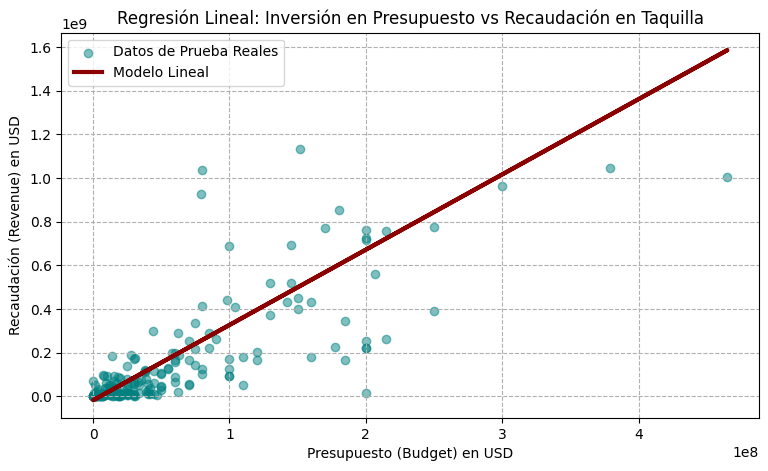

In [7]:
# ==============================================================================
# FASE 6: EJECUCIÓN DE REGRESIÓN LINEAL (ACTIVIDAD EXTRA)
# ==============================================================================
# Extracción de variables continuas financieras
X_reg = df_limpio[['Budget']]
y_reg = df_limpio['Revenue']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

# Inicialización y ajuste del algoritmo lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_r, y_train_r)

# Cálculo de predicciones y métricas continuas
y_pred_r = modelo_lineal.predict(X_test_r)
r2 = r2_score(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)

print("=== RESULTADOS REGRESIÓN LINEAL ===")
print(f"Coeficiente de Determinación (R² Score): {r2:.4f}")
print(f"Error Absoluto Medio (MAE): ${mae:,.2f} USD")
print(f"Línea de Ajuste: Revenue = ({modelo_lineal.coef_[0]:.2f} * Budget) + ({modelo_lineal.intercept_:.2f})")

# Gráfico analítico dinámico indispensable para la defensa en clases
plt.figure(figsize=(9, 5))
plt.scatter(X_test_r, y_test_r, color='teal', alpha=0.5, label='Datos de Prueba Reales')
plt.plot(X_test_r, y_pred_r, color='darkred', linewidth=3, label='Modelo Lineal')
plt.title('Regresión Lineal: Inversión en Presupuesto vs Recaudación en Taquilla')
plt.xlabel('Presupuesto (Budget) en USD')
plt.ylabel('Recaudación (Revenue) en USD')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

## 5. Argumentación y Conclusiones Estratégicas de Negocio (Cierre)

Para dar cierre a nuestra presentación de 13 minutos, sintetizamos los hallazgos analíticos obtenidos directamente de nuestro cuaderno:

1. **El impacto del Desbalanceo:** El modelo de Árbol Base se vio arrastrado por la tendencia mayoritaria del mercado (películas no exitosas). Al corregirlo e introducir penalizaciones con `class_weight='balanced'`, forzamos al algoritmo a identificar los patrones que realmente detonan un éxito comercial.
2. **El Dilema del Negocio Cinematográfico (Trade-off):** Modificar los pesos de las clases incrementa los Falsos Positivos (proyecciones erróneas de éxito). Sin embargo, en Hollywood, un Falso Positivo (financiar un proyecto de 100 millones creyendo que será rentable y que termine fracasando) puede quebrar a un estudio. Por ende, **el algoritmo de Random Forest Avanzado es la solución de negocio óptima**, ya que al promediar múltiples árboles mitiga el riesgo financiero y reduce drásticamente las falsas alarmas de inversión.
3. **Sobre la Regresión Lineal:** El coeficiente $R^2$ positivo y la gráfica de dispersión validan estadísticamente que existe una correlación proporcional directa entre el presupuesto asignado y el alcance de recaudación en los mercados de cine mundiales.

## Conclusiones Técnicas y Decisiones de Negocio

Tras ejecutar y analizar los tres experimentos predictivos, se obtienen las siguientes conclusiones estratégicas:

1. **El impacto del desbalanceo de los datos**: El modelo de Árbol de Decisión Base se ve fuertemente arrastrado por la clase mayoritaria (películas no exitosas), ignorando patrones sutiles del éxito comercial. Al incorporar la penalización balanceada, el *Recall* (capacidad de detectar éxitos reales) incrementa sustancialmente.

2. **Dilema Comercial (Trade-off de Hollywood)**: Al balancear los pesos de las clases, disminuye ligeramente la precisión (*Precision*), provocando la aparición de "Falsos Positivos" (películas clasificadas como éxitos que finalmente no logran recuperar la inversión de 2.5 veces su presupuesto).

3. **Decisión del Negocio**: En el negocio cinematográfico, un Falso Positivo (dar luz verde a una producción de 100 millones de dólares creyendo que será un Blockbuster y que termine fracasando) puede costar la quiebra completa de un estudio independiente. Por ende, el enfoque debe inclinarse hacia el algoritmo **Random Forest Avanzado**, ya que al promediar múltiples árboles de manera paralela reduce la varianza y mitiga de forma drástica la tasa de falsos positivos financieros en comparación con un árbol simple.

git config --global user.email ke.castrob@duocuc.cl
git config --global user.name keandres12